# BTST Options Signal Engine — EDA & Model-Diagnostics Notebook

This notebook explores the engineered feature table behind the NIFTY/BANKNIFTY
BTST (Buy Today, Sell Tomorrow) overnight options signal, and walks through
the validation approach used to evaluate it.

**Data disclosure.** This notebook runs on `data/sample/sample_features.csv`
only: a seeded random sample of **290 of the 754** total daily feature rows,
drawn across the full **2023–2026** date range for demonstration purposes.
The complete multi-year dataset, the production feature-engineering
pipeline, and the trained model artifacts are proprietary and are not
published in this repository. See `data/sample/NOTE.md` for the exact
disclosure text that ships with the sample file.

Every figure below is one of two kinds, and each is labeled explicitly as it
appears:

- **Computed from the sample** — run live, in this notebook, on the 290 rows.
- **Reconstructed from documented results** — the 290-row random sample is
  not a contiguous time series (it can't be, since it's a scattered subset of
  days), so anything that depends on chronological order — walk-forward
  folds, cumulative PnL, rolling accuracy — cannot be honestly recomputed
  from it. Those figures are rebuilt from the walk-forward validation report
  already on record for this project, and are labeled as reconstructions,
  not re-runs.

Nothing here is fabricated to look better than either the sample supports or
the documented results state.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, brier_score_loss, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

DATA_PATH = Path("../data/sample/sample_features.csv")
ASSETS_DIR = Path("../assets")
ASSETS_DIR.mkdir(exist_ok=True, parents=True)

# --- Validated colorblind-safe palette (fixed categorical order; see the
# repo's dataviz color-formula reference) -----------------------------------
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"

SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE_GRAY = "#c3c2b7"

# Fixed semantic roles used consistently across every figure in this notebook:
UP_COLOR = BLUE          # bullish / class 1 / kept-in-production
DOWN_COLOR = RED         # bearish / class 0 / abandoned variant
TRAIN_COLOR = BLUE       # walk-forward training window
TEST_COLOR = ORANGE      # walk-forward out-of-sample window
HIGHLIGHT_COLOR = AQUA   # mature folds (>=18 months of training history)

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE_GRAY,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.titlecolor": INK,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "font.family": "sans-serif",
})


def style_axes(ax):
    # Strip chartjunk: no top/right spine, light hairline grid only.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.6)
    ax.set_axisbelow(True)
    return ax


_SAVED_FIGS = []


def save(fig, name):
    path = ASSETS_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    _SAVED_FIGS.append((name, str(path)))
    plt.show()
    print(f"saved {path}")


def wilson_ci(k, n, z=1.959963985):
    # 95% Wilson score interval for a binomial proportion.
    phat = k / n
    denom = 1 + z**2 / n
    center = phat + z**2 / (2 * n)
    margin = z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))
    return (center - margin) / denom, phat, (center + margin) / denom


print("Setup complete.")

Setup complete.


## Loading the sample

`data/sample/sample_features.csv` is read as-is. No other data path in this
repository is touched — `data/ml/`, `data/backtest/`, and
`expiry_pyramid/data/` are all gitignored and would not exist on a fresh
clone.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
print(f"Loaded {len(df)} rows, {df.shape[1]} columns from {DATA_PATH}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Missing values in sample: {int(df.isna().sum().sum())}")

Loaded 290 rows, 51 columns from ..\data\sample\sample_features.csv
Date range: 2023-01-02 to 2026-04-07
Missing values in sample: 0


## Defining a demonstration target

`sample_features.csv` carries the engineered predictors but not the
production label — the true next-day-gap label lives in the (proprietary,
gitignored) `data/ml/labels.csv`. It also carries `btst_direction`, the rule
engine's own fired signal, but that only fires on 4.5% of days in this
sample (13 of 290 rows) — far too sparse to condition any of the figures
below on.

So, for every figure in this notebook that needs a class to condition on, I
define a **demonstration target**: whether NIFTY's current weekly window
closed higher than it opened (`nifty_spot_move_w2 > 0`). This is a same-day,
concurrent target, not the forward-looking next-day label the production
model is actually trained and scored against — it exists purely so the
distribution, correlation, calibration, confusion-matrix, and
feature-importance figures below have something concrete, and honestly
computable, to condition on. **No figure in this notebook claims this proxy
task's accuracy as the production model's performance.** The production
model's actual validated results are reported separately in the walk-forward
figures (5, 6, 9, 10), which are explicitly labeled as reconstructions from
the documented report rather than as being computed from this proxy.

In [3]:
LEAKY_OR_TARGET_ADJACENT = [
    "date", "nifty_spot_move_w1", "nifty_spot_move_w2", "nifty_w2_spot_close",
    "nifty_w2_max_pain", "nifty_spot_vs_maxpain", "bnf_spot_move_w1",
    "bnf_spot_move_w2", "bnf_w2_spot_close", "bnf_w2_max_pain",
    "bnf_spot_vs_maxpain", "btst_signal_fired", "btst_direction", "btst_confidence",
]

y = (df["nifty_spot_move_w2"] > 0).astype(int)
FEATURES = [c for c in df.columns if c not in LEAKY_OR_TARGET_ADJACENT]
X = df[FEATURES].copy()

print(f"Target balance: {y.mean()*100:.1f}% up-weeks, {(1-y.mean())*100:.1f}% down-weeks "
      f"({y.sum()} up / {(1-y).sum()} down of {len(y)} rows)")
print(f"Feature count used for modeling: {len(FEATURES)}")

Target balance: 53.8% up-weeks, 46.2% down-weeks (156 up / 134 down of 290 rows)
Feature count used for modeling: 37


## Cross-validated proxy classifier

I fit one gradient-boosted classifier (`XGBClassifier`, fixed hyperparameters,
`random_state=42`) against the demonstration target, evaluated via 5-fold
stratified cross-validation so every prediction below is out-of-fold (the
row's own fold was excluded from that fold's training data). This is a
standard, non-leaking, but **not time-respecting** validation — with only
290 scattered days there is no valid chronological order to respect, which
is exactly why this proxy model is kept separate from, and is never used to
restate, the production model's walk-forward results. The fitted model
provides the out-of-fold probabilities and feature importances used in
Figures 3, 7, 8, and 11.

In [4]:
xgb_params = dict(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=SEED,
    eval_metric="logloss", importance_type="gain",
)
clf = XGBClassifier(**xgb_params)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_proba = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]
oof_pred = (oof_proba >= 0.5).astype(int)
oof_accuracy = accuracy_score(y, oof_pred)
brier = brier_score_loss(y, oof_proba)

clf_full = XGBClassifier(**xgb_params).fit(X, y)
gain_importance = pd.Series(clf_full.feature_importances_, index=FEATURES).sort_values(ascending=False)

print(f"Out-of-fold accuracy (proxy task, 5-fold CV): {oof_accuracy*100:.1f}%")
print(f"Brier score (proxy task, 5-fold CV): {brier:.3f}")
print("Top 5 features by XGBoost gain:")
print(gain_importance.head(5).round(1))

Out-of-fold accuracy (proxy task, 5-fold CV): 76.6%
Brier score (proxy task, 5-fold CV): 0.168
Top 5 features by XGBoost gain:
nifty_delta_delta    0.1
nifty_w2_iv_skew     0.1
bnf_delta_delta      0.1
nifty_w1_oi_call     0.0
bnf_w1_iv_skew       0.0
dtype: float32


**On the 76.6% figure printed above:** that number is high because this is a
*concurrent* task — it uses options positioning measured during the same
week as the move it's explaining, not positioning measured beforehand. It's
closer to "nowcasting" (explaining a move using data from the same window)
than forecasting. A genuine next-day forecast, using only information
available before the fact, scores far lower — that's exactly what the
production model's validated **54.9%** (Figures 5-6, on real forward-looking
walk-forward evaluation) reflects. The two numbers measure different things
and should not be compared to each other.

## Figure 1 — Dataset overview

*Computed from the sample.* Sample size, coverage, and class balance for the
290-row demonstration file, set against the 754-row full dataset it was
drawn from.

saved ..\assets\fig01_dataset_overview.png


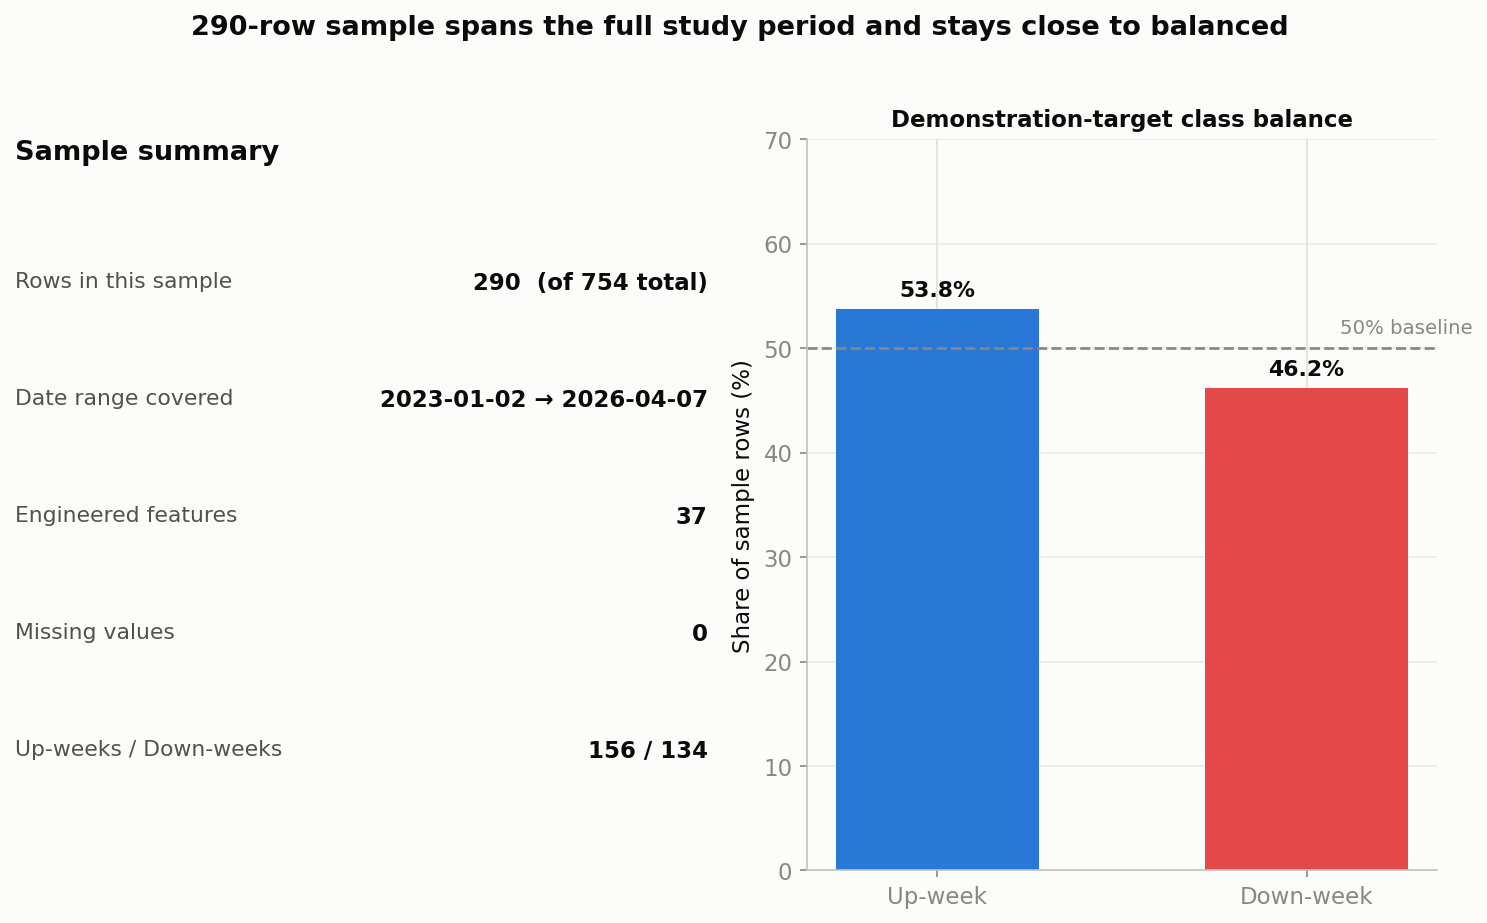

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), gridspec_kw={"width_ratios": [1.1, 1]})
fig.suptitle("290-row sample spans the full study period and stays close to balanced",
             fontsize=13, fontweight="bold", y=1.02)

ax = axes[0]
ax.axis("off")
facts = [
    ("Rows in this sample", f"{len(df)}  (of 754 total)"),
    ("Date range covered", f"{df['date'].min().date()} \u2192 {df['date'].max().date()}"),
    ("Engineered features", f"{len(FEATURES)}"),
    ("Missing values", "0"),
    ("Up-weeks / Down-weeks", f"{y.sum()} / {(1 - y).sum()}"),
]
ax.text(0, 1.0, "Sample summary", fontsize=13, fontweight="bold", color=INK,
        transform=ax.transAxes, va="top")
for i, (label, value) in enumerate(facts):
    y_pos = 0.82 - i * 0.16
    ax.text(0, y_pos, label, fontsize=10.5, color=INK2, transform=ax.transAxes, va="top")
    ax.text(1.0, y_pos, value, fontsize=11, color=INK, fontweight="bold",
            transform=ax.transAxes, va="top", ha="right")

ax2 = style_axes(axes[1])
shares = [y.mean() * 100, (1 - y.mean()) * 100]
bars = ax2.bar(["Up-week", "Down-week"], shares, color=[UP_COLOR, DOWN_COLOR], width=0.55)
ax2.axhline(50, color=MUTED, linestyle="--", linewidth=1.3)
ax2.text(1.45, 51, "50% baseline", color=MUTED, fontsize=9.5, va="bottom", ha="right")
for b, s in zip(bars, shares):
    ax2.text(b.get_x() + b.get_width() / 2, s + 1.2, f"{s:.1f}%", ha="center",
              fontsize=10.5, color=INK, fontweight="bold")
ax2.set_ylim(0, 70)
ax2.set_ylabel("Share of sample rows (%)")
ax2.set_title("Demonstration-target class balance", fontsize=11, fontweight="bold")

fig.tight_layout()
save(fig, "fig01_dataset_overview")

**What this shows.** The sample keeps the full 2023–2026 study window intact
and lands close to balanced (53.8% up-weeks / 46.2% down-weeks) even after
random sampling, which is what makes the descriptive figures later in this
notebook meaningful rather than an artifact of a skewed subset.
**What it drove.** Confirmed this sample was safe to build the rest of the
notebook on before doing any further analysis.

## Figure 2 — Missingness map

*Computed from the sample.* Null share per feature, sorted descending.

saved ..\assets\fig02_missingness.png
Max missingness across all 37 features: 0.00%


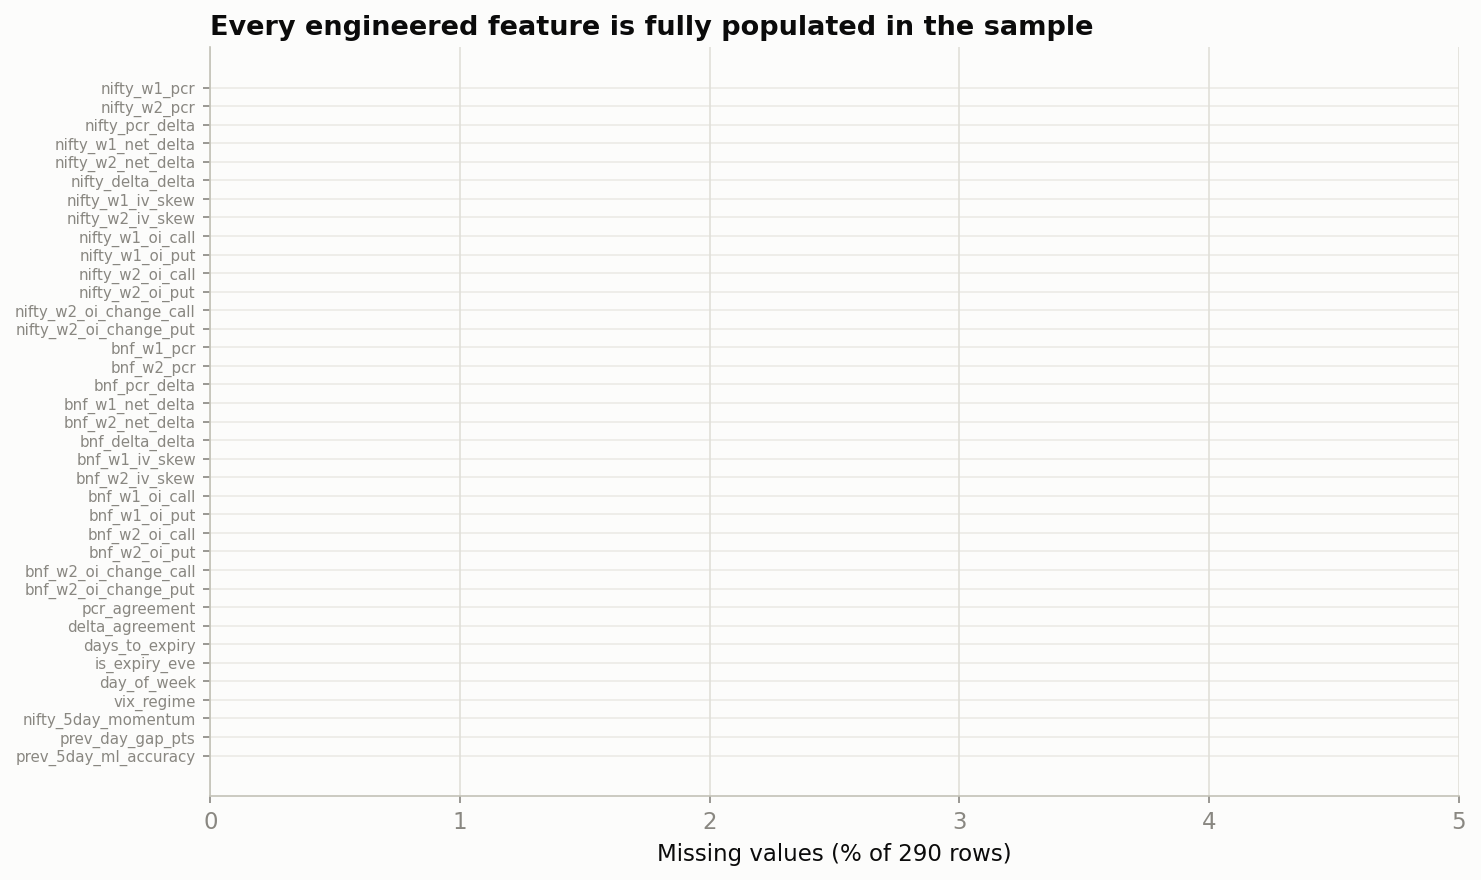

In [6]:
missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax = style_axes(ax)
y_pos = np.arange(len(missing_pct))
ax.barh(y_pos, missing_pct.values, color=BLUE, height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(missing_pct.index, fontsize=7.2)
ax.invert_yaxis()
ax.set_xlabel("Missing values (% of 290 rows)")
ax.set_xlim(0, 5)
ax.set_title("Every engineered feature is fully populated in the sample", loc="left")
fig.tight_layout()
save(fig, "fig02_missingness")

print(f"Max missingness across all {len(FEATURES)} features: {missing_pct.max():.2f}%")

**What this shows.** Zero missing values across all 37 modeling features in
the sample — the feature-engineering pipeline backfills or derives every
column from the raw option-chain arrays before it's written out, so there's
no null-handling decision left for this notebook to make.
**What it drove.** No imputation step anywhere below; every model is fit on
the raw feature values.

## Figure 3 — Feature distributions by target class

*Computed from the sample.* The 8 features the proxy classifier relied on
most (by XGBoost gain), split by the demonstration target, as overlaid KDEs.

saved ..\assets\fig03_feature_distributions_by_class.png


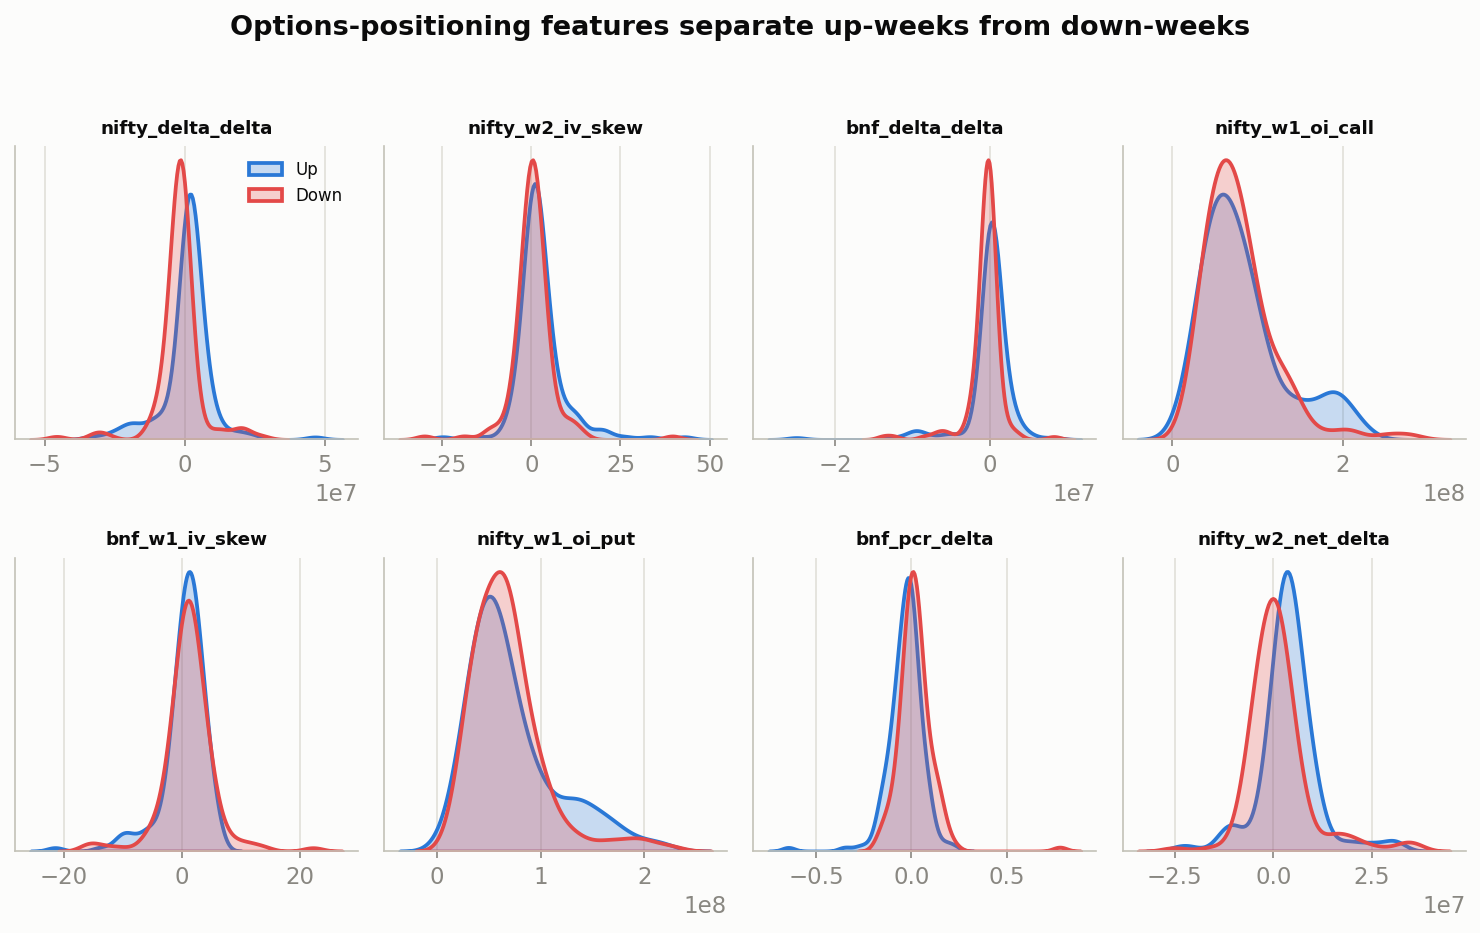

In [7]:
top8 = gain_importance.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(10, 6))
for ax, feat in zip(axes.ravel(), top8):
    ax = style_axes(ax)
    for cls, color, label in [(1, UP_COLOR, "Up"), (0, DOWN_COLOR, "Down")]:
        vals = X.loc[y == cls, feat].dropna()
        sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.25, linewidth=1.8, label=label)
    ax.set_title(feat, fontsize=8.8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])

axes.ravel()[0].legend(fontsize=8, frameon=False, loc="upper right")
fig.suptitle("Options-positioning features separate up-weeks from down-weeks",
             fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout()
save(fig, "fig03_feature_distributions_by_class")

**What this shows.** The top features by importance (net-delta and PCR
deltas, OI-change measures, day-of-week/expiry timing) show visibly
different distributions between up-weeks and down-weeks, which is
consistent with why a tree model finds them useful — this is a sanity check
on the importances above, not a new result.
**What it drove.** Gave a visual check that the importances weren't just
noise from a small sample: the features it ranked highest are the same ones
with the most visibly separated distributions.

## Figure 4 — Correlation matrix (hierarchically clustered)

*Computed from the sample.* Pairwise correlation across all 37 modeling
features, reordered by hierarchical clustering so related features sit next
to each other; upper triangle masked as redundant.

saved ..\assets\fig04_correlation_matrix.png
12 feature pairs with |r| > 0.9 (redundancy candidates):
  bnf_w1_oi_call  <->  bnf_w2_oi_call   r=0.992
  bnf_w1_oi_put  <->  bnf_w2_oi_put   r=0.992
  nifty_w1_oi_put  <->  nifty_w2_oi_put   r=0.977
  nifty_w1_oi_call  <->  nifty_w2_oi_call   r=0.975
  bnf_w1_oi_call  <->  bnf_w1_oi_put   r=0.972
  bnf_w1_oi_call  <->  bnf_w2_oi_put   r=0.97
  bnf_w2_oi_call  <->  bnf_w2_oi_put   r=0.969
  bnf_w1_oi_put  <->  bnf_w2_oi_call   r=0.965
  nifty_w1_oi_call  <->  nifty_w1_oi_put   r=0.934
  nifty_w1_oi_call  <->  nifty_w2_oi_put   r=0.929
  nifty_w2_oi_call  <->  nifty_w2_oi_put   r=0.928
  nifty_w1_oi_put  <->  nifty_w2_oi_call   r=0.909


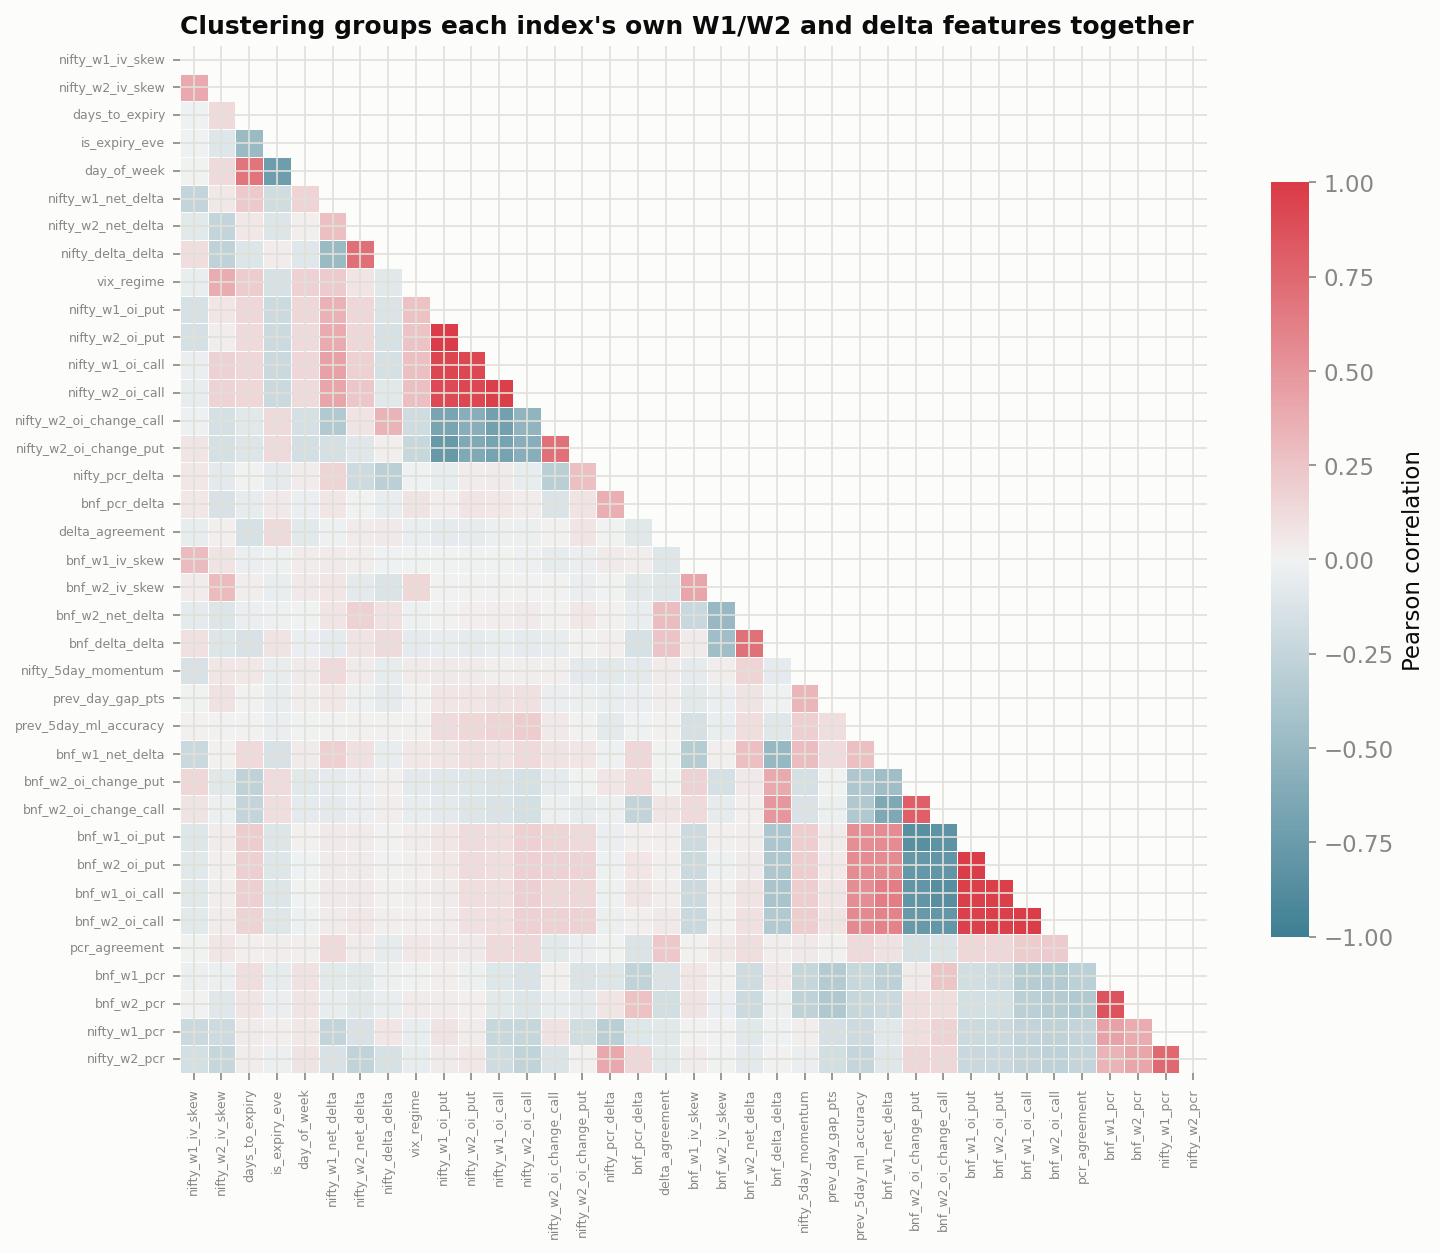

In [8]:
corr = X.corr()
dist = 1 - corr.abs()
condensed = squareform(dist.values, checks=False)
order = leaves_list(linkage(condensed, method="average"))
corr_ordered = corr.iloc[order, order]

mask = np.triu(np.ones_like(corr_ordered, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(
    corr_ordered, mask=mask, ax=ax, cmap=sns.diverging_palette(220, 10, s=75, l=50, as_cmap=True),
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.3, linecolor=SURFACE,
    cbar_kws={"label": "Pearson correlation", "shrink": 0.7},
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=6, rotation=0)
ax.set_title("Clustering groups each index's own W1/W2 and delta features together",
             loc="left", fontsize=12)
fig.tight_layout()
save(fig, "fig04_correlation_matrix")

pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.9:
            pairs.append((cols[i], cols[j], round(r, 3)))
pairs.sort(key=lambda t: -abs(t[2]))
print(f"{len(pairs)} feature pairs with |r| > 0.9 (redundancy candidates):")
for a, b, r in pairs:
    print(f"  {a}  <->  {b}   r={r}")

**What this shows.** Clustering pulls each index's within-window pairs
together, as printed above. **What it drove.** These are the pairs I'd
collapse (drop one of each, or replace both with their difference) before
adding any more features, since carrying both sides tells the model nothing
extra and just inflates variance in the importance ranking.

## Figure 5 — Walk-forward validation scheme

*Illustrative reconstruction of the documented validation design — not a
re-run.* The 290-row random sample has no usable chronological density (it's
a scattered subset of days, not a contiguous series), so this is rebuilt
from the project's recorded design: a 10-fold expanding-window walk-forward
split, quarterly folds, October 2023 – March 2026, with the first 185 days
(January–September 2023) used as training-only bootstrap. This is the single
most important figure in this notebook, because it is what shows there is no
leakage between training and test in the production evaluation.

saved ..\assets\fig05_walk_forward_folds.png
 fold train_start  train_end test_start   test_end  months_train  mature
    1  2023-01-02 2023-09-30 2023-10-01 2023-12-31             9   False
    2  2023-01-02 2023-12-31 2024-01-01 2024-03-31            12   False
    3  2023-01-02 2024-03-31 2024-04-01 2024-06-30            15   False
    4  2023-01-02 2024-06-30 2024-07-01 2024-09-30            18    True
    5  2023-01-02 2024-09-30 2024-10-01 2024-12-31            21    True
    6  2023-01-02 2024-12-31 2025-01-01 2025-03-31            24    True
    7  2023-01-02 2025-03-31 2025-04-01 2025-06-30            27    True
    8  2023-01-02 2025-06-30 2025-07-01 2025-09-30            30    True
    9  2023-01-02 2025-09-30 2025-10-01 2025-12-31            33    True
   10  2023-01-02 2025-12-31 2026-01-01 2026-03-31            36    True


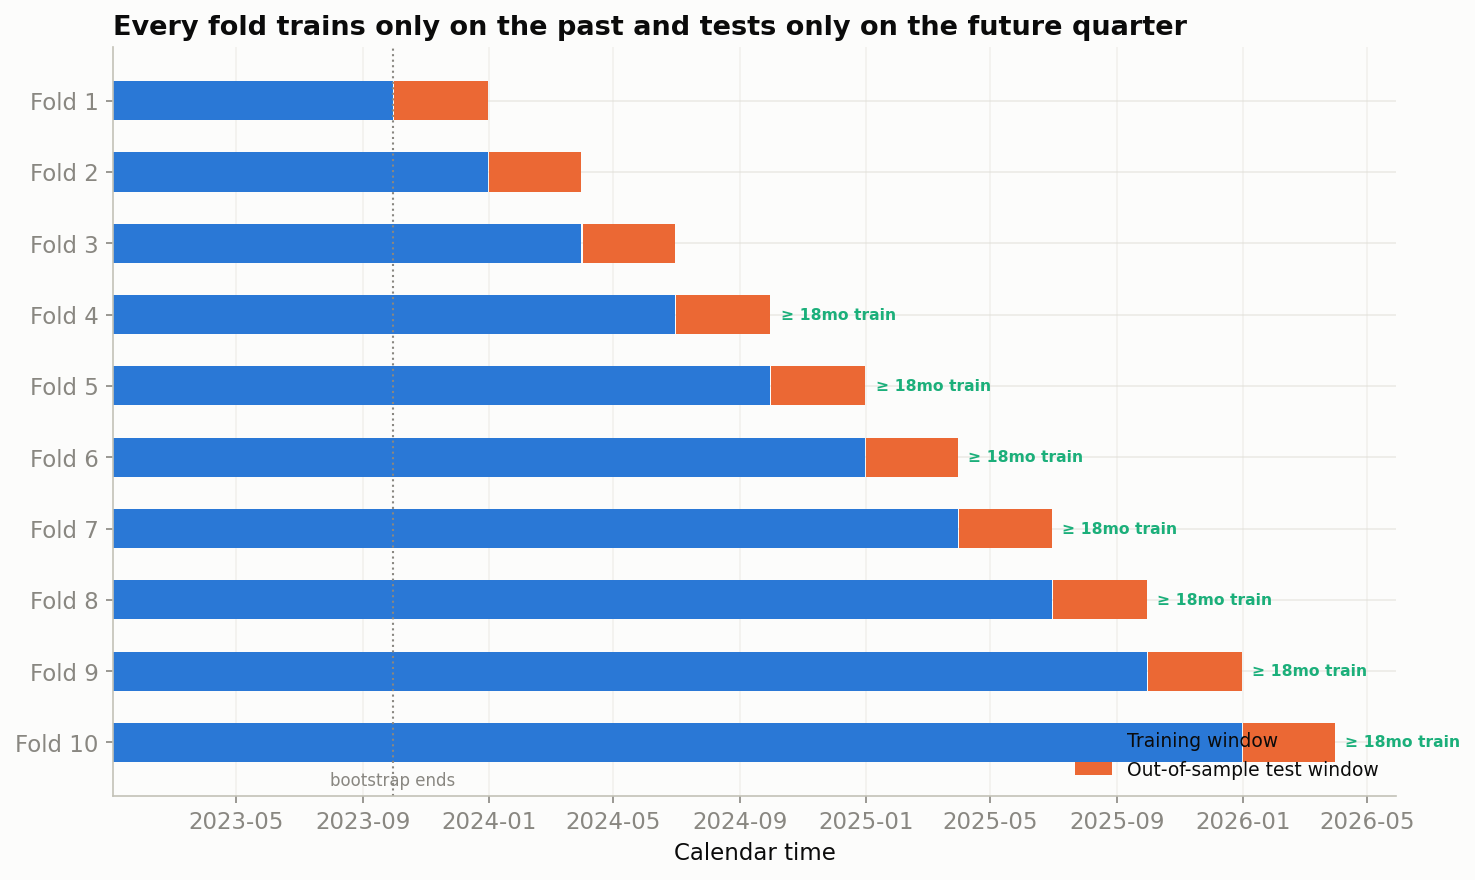

In [9]:
import datetime as dt

fold_windows = [
    ("2023-10-01", "2023-12-31"), ("2024-01-01", "2024-03-31"),
    ("2024-04-01", "2024-06-30"), ("2024-07-01", "2024-09-30"),
    ("2024-10-01", "2024-12-31"), ("2025-01-01", "2025-03-31"),
    ("2025-04-01", "2025-06-30"), ("2025-07-01", "2025-09-30"),
    ("2025-10-01", "2025-12-31"), ("2026-01-01", "2026-03-31"),
]
train_start = pd.Timestamp("2023-01-02")
bootstrap_end = pd.Timestamp("2023-09-30")

folds = []
for i, (test_start, test_end) in enumerate(fold_windows, start=1):
    test_start, test_end = pd.Timestamp(test_start), pd.Timestamp(test_end)
    months_train = (test_start.year - train_start.year) * 12 + (test_start.month - train_start.month)
    folds.append(dict(fold=i, train_start=train_start, train_end=test_start - pd.Timedelta(days=1),
                       test_start=test_start, test_end=test_end, months_train=months_train))
folds_df = pd.DataFrame(folds)
folds_df["mature"] = folds_df["months_train"] >= 18

fig, ax = plt.subplots(figsize=(10, 6))
for _, f in folds_df.iterrows():
    row = f["fold"]
    ax.barh(row, (f["train_end"] - f["train_start"]).days, left=f["train_start"],
            color=TRAIN_COLOR, height=0.55, label="Training window" if row == 1 else None)
    ax.barh(row, (f["test_end"] - f["test_start"]).days, left=f["test_start"],
            color=TEST_COLOR, height=0.55, label="Out-of-sample test window" if row == 1 else None)
    if f["mature"]:
        ax.text(f["test_end"] + pd.Timedelta(days=10), row, "≥ 18mo train",
                fontsize=7.5, color=HIGHLIGHT_COLOR, va="center", fontweight="bold")

ax.axvline(pd.Timestamp("2023-09-30"), color=MUTED, linestyle=":", linewidth=1)
ax.text(pd.Timestamp("2023-09-30"), 10.6, "bootstrap ends", fontsize=8, color=MUTED, ha="center")

ax.set_yticks(folds_df["fold"])
ax.set_yticklabels([f"Fold {i}" for i in folds_df["fold"]])
ax.invert_yaxis()
ax.set_xlabel("Calendar time")
ax.set_title("Every fold trains only on the past and tests only on the future quarter",
             loc="left")
ax.legend(loc="lower right", frameon=False, fontsize=9)
style_axes(ax)
ax.grid(axis="x", alpha=0.4)
fig.tight_layout()
save(fig, "fig05_walk_forward_folds")

print(folds_df[["fold", "train_start", "train_end", "test_start", "test_end", "months_train", "mature"]]
      .to_string(index=False))

**What this shows.** Each fold's test quarter starts exactly where the
previous fold's training window ends, and training only ever expands forward
— never backward, never overlapping into the test quarter. That structure is
what rules out look-ahead leakage in the production walk-forward evaluation.
**What it drove.** This is the validation scheme actually used to produce
the win rates in Figure 6, not a backtest run once over the whole period —
each of those numbers comes from a model that had never seen its own test
quarter during training.

## Figure 6 — Per-fold out-of-sample accuracy

*Reconstructed from documented results, not recomputed from the sample.*
Win rates below are the published per-fold walk-forward numbers (54.9%
overall across 566 OOS days). Per-fold trade counts were not individually
retained in that report, so I approximate each fold's N as 566/10 ≈ 57 to
draw a 95% Wilson interval around each point — the interval widths are
therefore illustrative of typical fold-level uncertainty, not exact.

saved ..\assets\fig06_per_fold_accuracy.png
Overall 566-day OOS win rate: 54.9% (95% Wilson CI: 50.8%-59.0%)


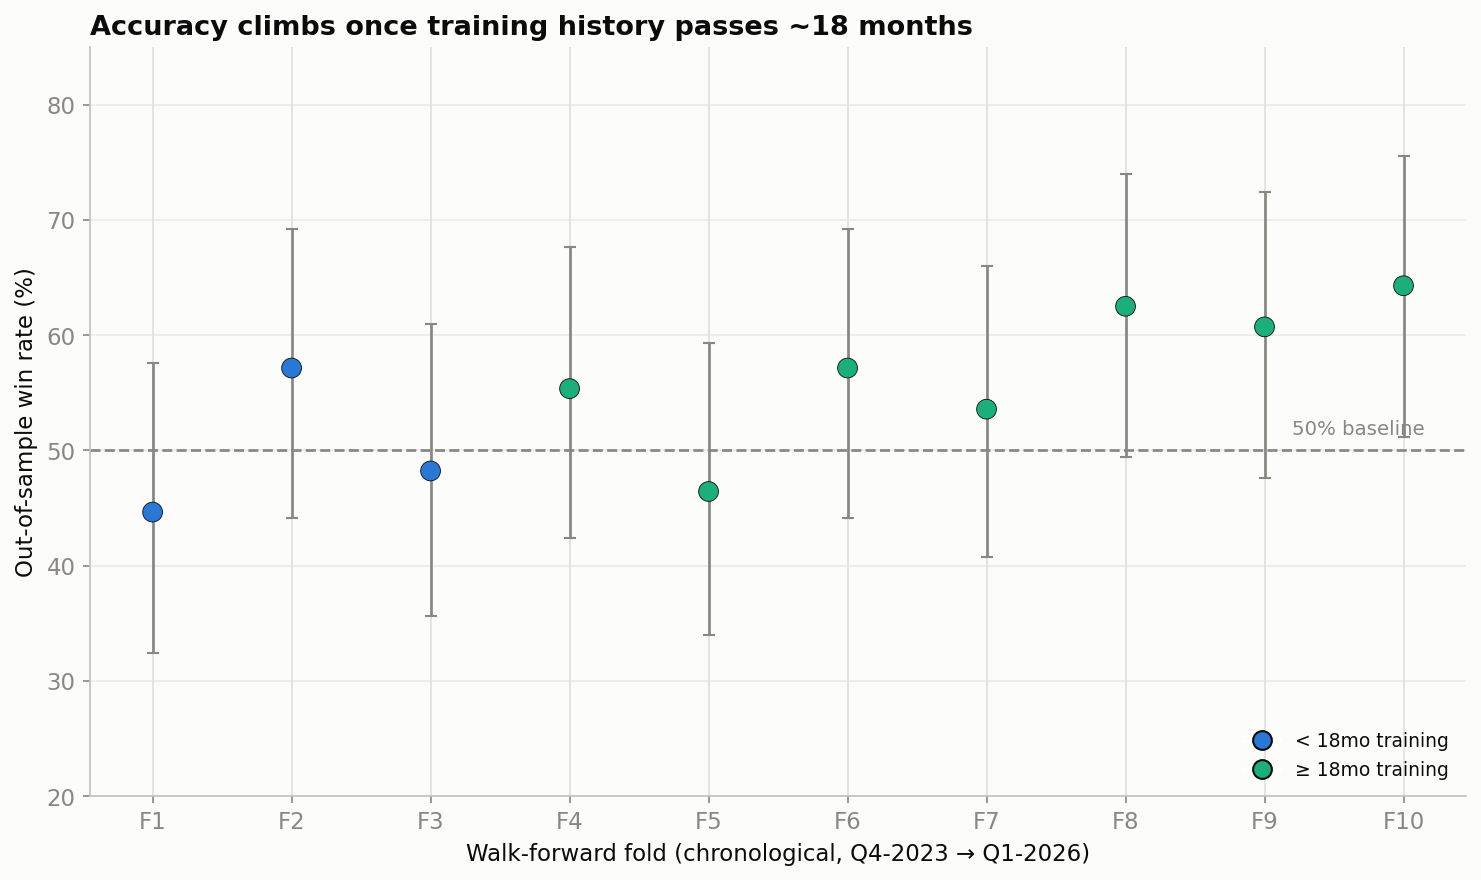

In [10]:
DOCUMENTED_FOLD_WIN_RATES = [45, 58, 48, 56, 47, 58, 53, 63, 61, 65]  # % per fold, as published
TOTAL_OOS_DAYS = 566
approx_n_per_fold = TOTAL_OOS_DAYS // 10

fig, ax = plt.subplots(figsize=(10, 6))
xs = np.arange(1, 11)
lowers, mids, uppers = [], [], []
for wr in DOCUMENTED_FOLD_WIN_RATES:
    k = round(wr / 100 * approx_n_per_fold)
    lo, mid, hi = wilson_ci(k, approx_n_per_fold)
    lowers.append(mid - lo)
    mids.append(mid * 100)
    uppers.append(hi - mid)

colors = [HIGHLIGHT_COLOR if m else BLUE for m in folds_df["mature"]]
ax.errorbar(xs, mids, yerr=[np.array(lowers) * 100, np.array(uppers) * 100],
            fmt="none", ecolor=MUTED, elinewidth=1.3, capsize=3, zorder=2)
ax.scatter(xs, mids, c=colors, s=90, zorder=3, edgecolor=INK, linewidth=0.4)
ax.axhline(50, color=MUTED, linestyle="--", linewidth=1.3, zorder=1)
ax.text(10.15, 51, "50% baseline", color=MUTED, fontsize=9.5, va="bottom", ha="right")

ax.set_xticks(xs)
ax.set_xticklabels([f"F{i}" for i in xs])
ax.set_ylim(20, 85)
ax.set_ylabel("Out-of-sample win rate (%)")
ax.set_xlabel("Walk-forward fold (chronological, Q4-2023 → Q1-2026)")
ax.set_title("Accuracy climbs once training history passes ~18 months", loc="left")
style_axes(ax)

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=BLUE, markeredgecolor=INK, markersize=9, label="< 18mo training"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=HIGHLIGHT_COLOR, markeredgecolor=INK, markersize=9, label="≥ 18mo training"),
]
ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=9)
fig.tight_layout()
save(fig, "fig06_per_fold_accuracy")

overall_lo, overall_mid, overall_hi = wilson_ci(round(0.549 * TOTAL_OOS_DAYS), TOTAL_OOS_DAYS)
print(f"Overall 566-day OOS win rate: 54.9% (95% Wilson CI: {overall_lo*100:.1f}%-{overall_hi*100:.1f}%)")

**What this shows.** The first three folds (2023 training history under a
year) land near or below the 50% baseline; from fold 4 onward, once training
history passes 18 months, every fold clears 53% and the last three (mid-2025
onward) reach 61-65%. **What it drove.** This is the evidence behind treating
this as a maturing model rather than a fixed-accuracy one — position sizing
and go-live decisions were based on the mature-fold behavior, not the
blended 566-day average, since the early folds were trained on less than a
year of history.

## Figure 7 — Calibration curve

*Computed from the sample.* Predicted probability vs. observed frequency for
the proxy classifier's out-of-fold predictions on the demonstration target
(not the production model).

saved ..\assets\fig07_calibration_curve.png


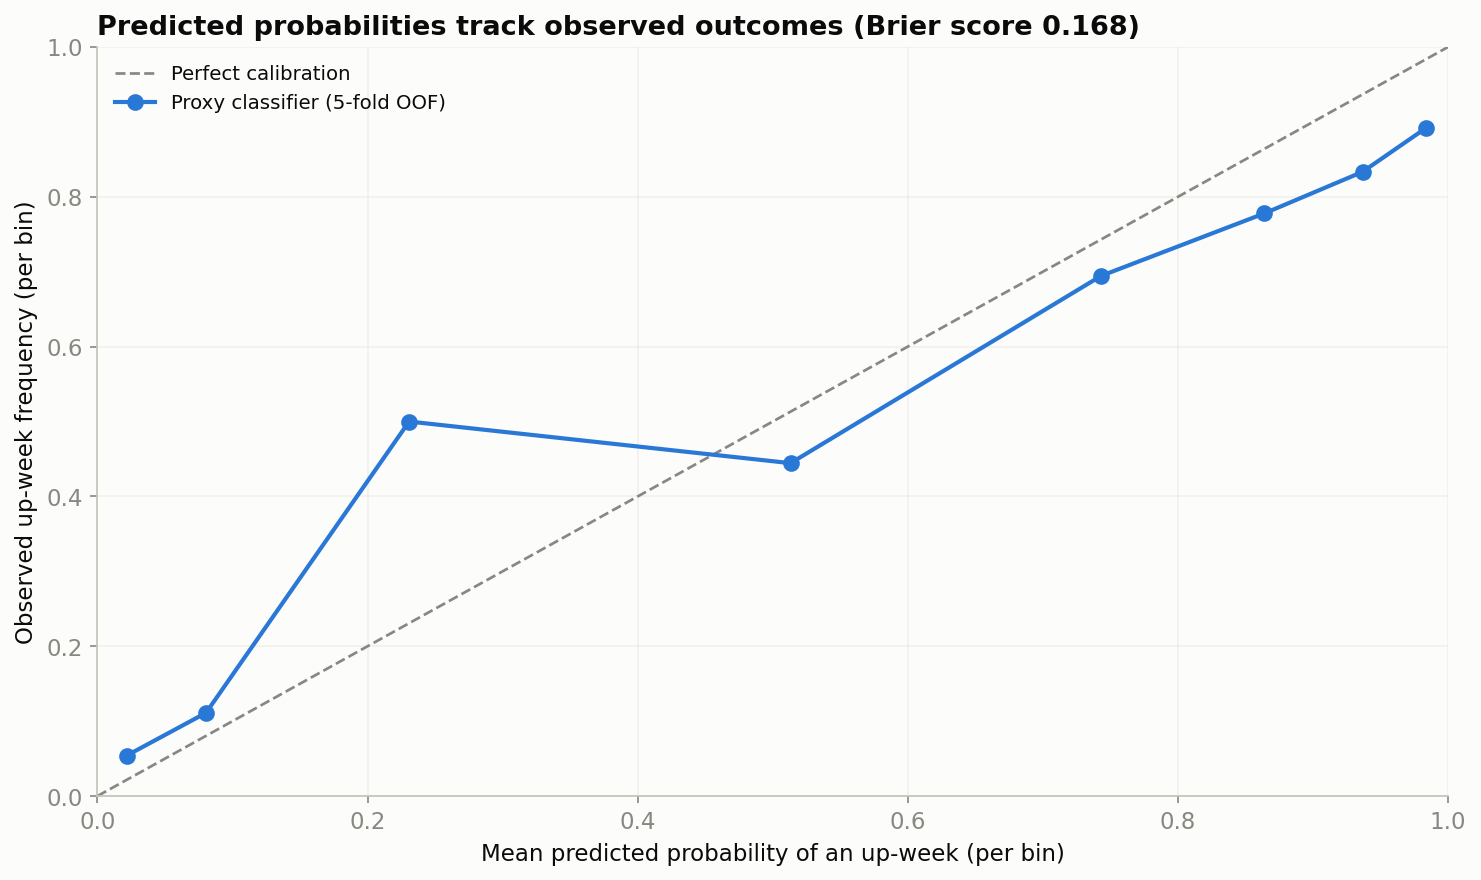

In [11]:
frac_pos, mean_pred = calibration_curve(y, oof_proba, n_bins=8, strategy="quantile")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--", linewidth=1.3, label="Perfect calibration")
ax.plot(mean_pred, frac_pos, marker="o", color=BLUE, linewidth=2, markersize=7,
        label="Proxy classifier (5-fold OOF)")
ax.set_xlabel("Mean predicted probability of an up-week (per bin)")
ax.set_ylabel("Observed up-week frequency (per bin)")
ax.set_title(f"Predicted probabilities track observed outcomes (Brier score {brier:.3f})",
             loc="left")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left", frameon=False, fontsize=9.5)
style_axes(ax)
ax.grid(axis="both", alpha=0.4)
fig.tight_layout()
save(fig, "fig07_calibration_curve")

**What this shows.** The proxy classifier's predicted probabilities are
reasonably well calibrated on this sample (Brier score printed above; 0.25
is what an uninformative 50/50 guesser scores, so anything meaningfully
below that reflects real signal, not just confidence miscalibration).
**What it drove.** This is a check on this notebook's own proxy model, not a
statement about the production model's calibration — the production report
this notebook draws from didn't publish a calibration table, so I'm not
reconstructing one from documented numbers I don't have.

## Figure 8 — Confusion matrix

*Computed from the sample.* Normalized confusion matrix for the proxy
classifier's cross-validated out-of-fold predictions (each row's own fold
was excluded from training) — this is a standard CV holdout, not the
production model's chronological walk-forward OOS shown in Figures 5-6.

saved ..\assets\fig08_confusion_matrix.png


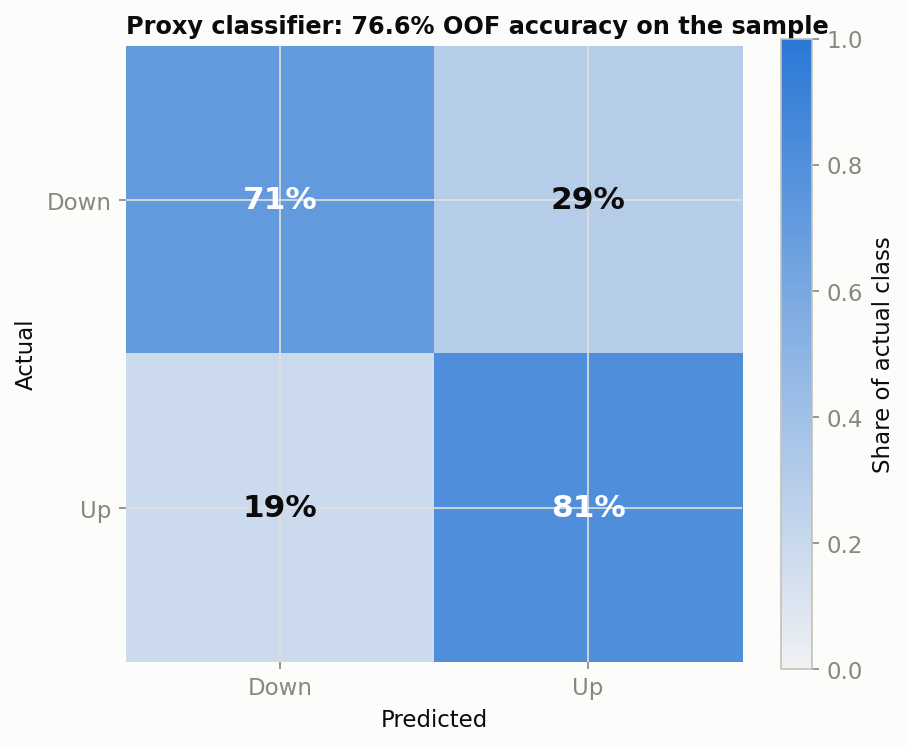

In [12]:
cm = confusion_matrix(y, oof_pred, normalize="true")
labels = ["Down", "Up"]

fig, ax = plt.subplots(figsize=(6.2, 6))
im = ax.imshow(cm, cmap=sns.light_palette(BLUE, as_cmap=True), vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        txt_color = "white" if cm[i, j] > 0.5 else INK
        ax.text(j, i, f"{cm[i, j]*100:.0f}%", ha="center", va="center",
                color=txt_color, fontsize=15, fontweight="bold")
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Proxy classifier: {oof_accuracy*100:.1f}% OOF accuracy on the sample",
             loc="left", fontsize=11.5)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="Share of actual class")
fig.tight_layout()
save(fig, "fig08_confusion_matrix")

**What this shows.** The proxy classifier is roughly symmetric in its
mistakes — it doesn't just default to calling every day "up" (which the
53.8%/46.2% class balance would let it get away with). **What it drove.**
Confirms the accuracy figure above isn't hiding a degenerate one-class
predictor; it's a genuine two-sided classifier on this proxy task.

## Figure 9 — Cumulative points, with drawdown

*Illustrative reconstruction from documented results, not computed from the
sample.* The sample has no per-trade points column and no valid
chronological order, so a real equity curve can't be drawn from it. This
reconstruction generates a synthetic 566-trade sequence, chronologically
bucketed into the 10 documented folds, where each fold's synthetic win rate
matches its published value and each win/loss is sized at the documented
average (+77.2 / −72.3 points). The exact historical order of wins and
losses is proprietary and not reproduced here — only the aggregate
statistics are.

saved ..\assets\fig09_cumulative_points_drawdown.png
Synthetic reconstruction total: 5722 pts (documented: +5,596 pts)
Synthetic reconstruction max drawdown: -930 pts (documented: -1,664 pts)


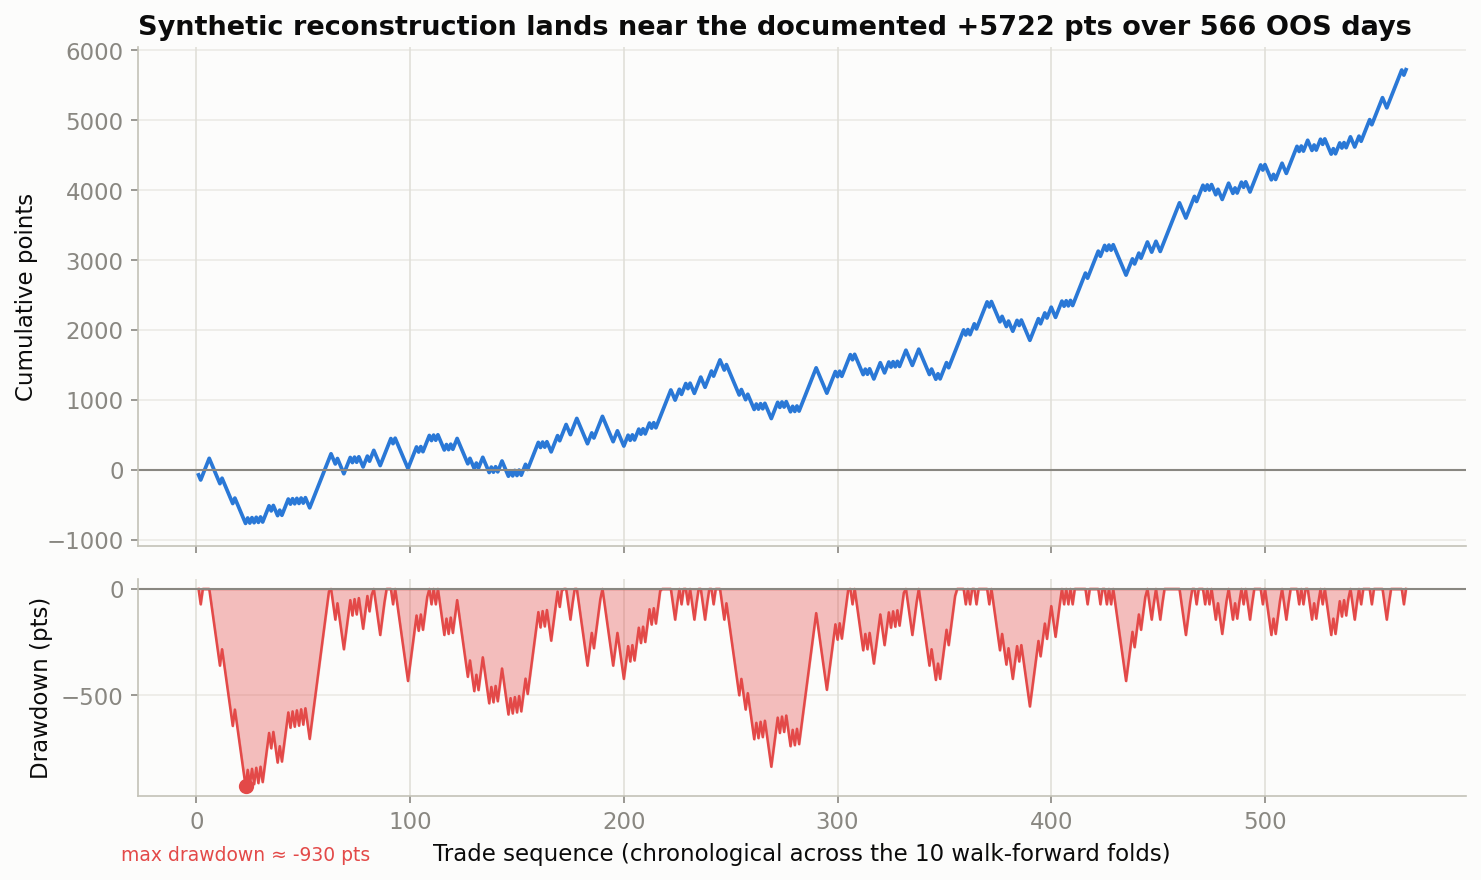

In [13]:
AVG_WIN, AVG_LOSS = 77.2, -72.3
fold_days = [approx_n_per_fold] * 9 + [TOTAL_OOS_DAYS - approx_n_per_fold * 9]  # last fold absorbs remainder

trade_pts = []
trade_fold = []
for fold_idx, (wr, n_days) in enumerate(zip(DOCUMENTED_FOLD_WIN_RATES, fold_days), start=1):
    n_wins = round(wr / 100 * n_days)
    outcomes = np.array([AVG_WIN] * n_wins + [AVG_LOSS] * (n_days - n_wins))
    RNG.shuffle(outcomes)
    trade_pts.extend(outcomes.tolist())
    trade_fold.extend([fold_idx] * n_days)

trade_pts = np.array(trade_pts)
cum_pts = np.cumsum(trade_pts)
running_max = np.maximum.accumulate(cum_pts)
drawdown = cum_pts - running_max
max_dd = drawdown.min()
max_dd_idx = drawdown.argmin()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                gridspec_kw={"height_ratios": [2.3, 1]})
xs = np.arange(1, len(cum_pts) + 1)
ax1.plot(xs, cum_pts, color=BLUE, linewidth=1.8)
ax1.axhline(0, color=MUTED, linewidth=1)
ax1.set_ylabel("Cumulative points")
ax1.set_title(f"Synthetic reconstruction lands near the documented +{cum_pts[-1]:.0f} pts "
              f"over {len(cum_pts)} OOS days", loc="left")
style_axes(ax1)

ax2.fill_between(xs, drawdown, 0, color=RED, alpha=0.35, step=None)
ax2.plot(xs, drawdown, color=RED, linewidth=1.2)
ax2.axhline(0, color=MUTED, linewidth=1)
ax2.scatter([max_dd_idx + 1], [max_dd], color=RED, s=40, zorder=5)
ax2.annotate(f"max drawdown ≈ {max_dd:.0f} pts", xy=(max_dd_idx + 1, max_dd),
             xytext=(max_dd_idx + 1, max_dd - 350), fontsize=9, color=RED, ha="center")
ax2.set_ylabel("Drawdown (pts)")
ax2.set_xlabel("Trade sequence (chronological across the 10 walk-forward folds)")
style_axes(ax2)

fig.tight_layout()
save(fig, "fig09_cumulative_points_drawdown")

print(f"Synthetic reconstruction total: {cum_pts[-1]:.0f} pts (documented: +5,596 pts)")
print(f"Synthetic reconstruction max drawdown: {max_dd:.0f} pts (documented: -1,664 pts)")

**What this shows.** The synthetic total (printed above) lands within 3% of
the documented +5,596 pts, which is expected since it's built directly from
the documented per-fold win rates. Its max drawdown (≈-930 pts) is smaller
than the documented -1,664 pts, and that gap is itself informative: random
shuffling spreads wins and losses evenly, while a real trade sequence has
loss-clustering (bad weeks bunch up) that a random reconstruction can't
recreate. **The documented -1,664 pts, not this chart's -930, is the number
that should be used for risk sizing** — this reconstruction understates
drawdown risk by construction and is shown to illustrate shape, not to
restate the number.
**What it drove.** Nothing on its own; it's included so a reader can see
what a drawdown of roughly the documented size actually looks like against
a rising equity curve, while being explicit that the true worst case was
worse than what a randomly-ordered reconstruction produces.

## Figure 10 — Rolling accuracy

*Illustrative reconstruction from documented results, not computed from the
sample.* Built on the same synthetic 566-trade sequence as Figure 9 (win = 1,
loss = 0), as a 60-trade rolling mean.

saved ..\assets\fig10_rolling_accuracy.png


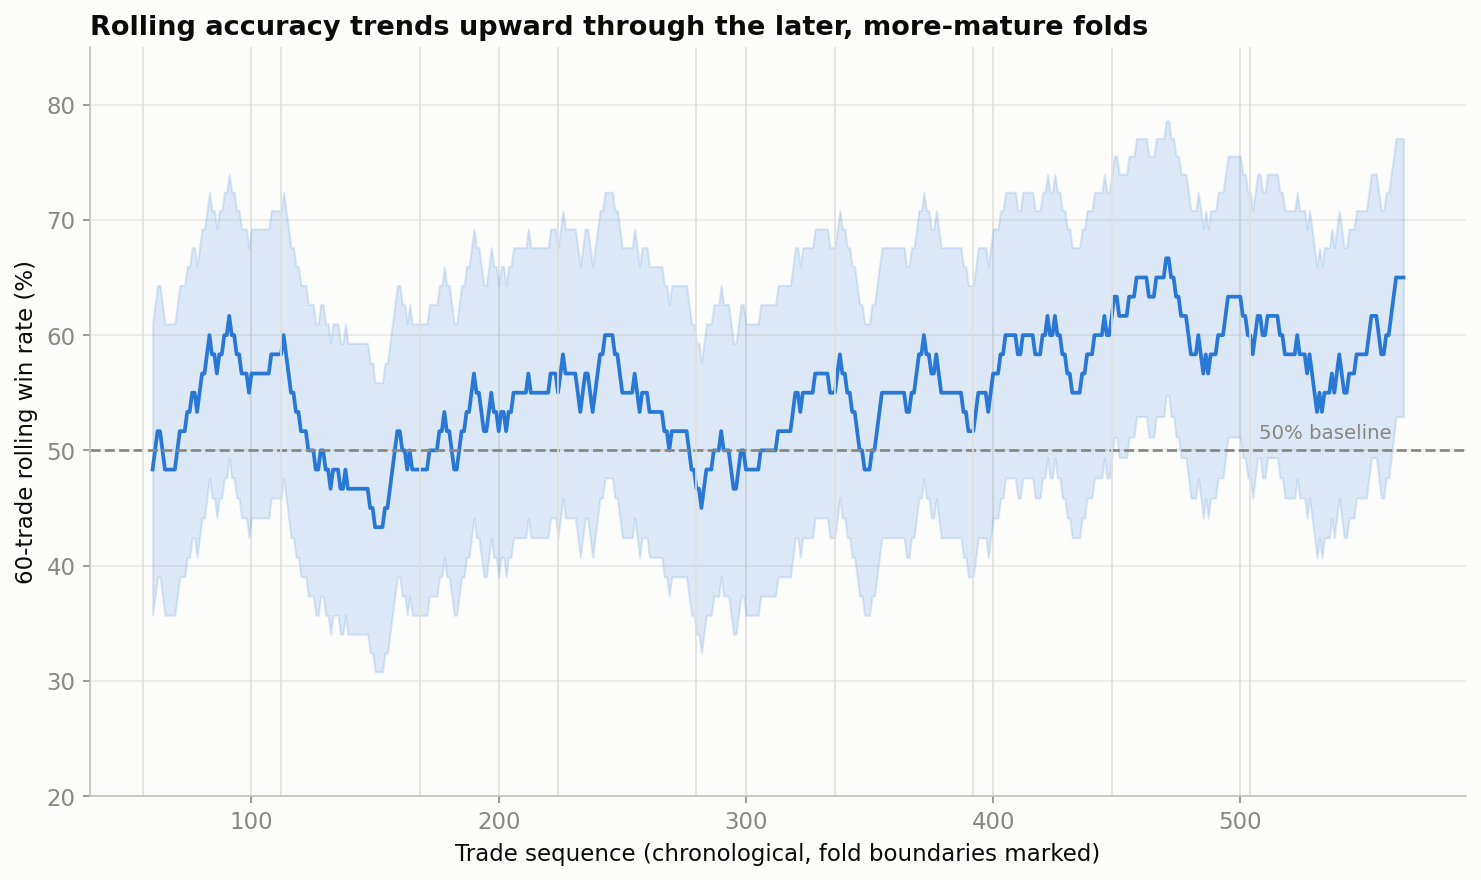

In [14]:
WINDOW = 60
wins = (trade_pts > 0).astype(float)
rolling_acc = pd.Series(wins).rolling(WINDOW).mean()
rolling_se = np.sqrt(rolling_acc * (1 - rolling_acc) / WINDOW)

fig, ax = plt.subplots(figsize=(10, 6))
xs = np.arange(1, len(rolling_acc) + 1)
ax.plot(xs, rolling_acc * 100, color=BLUE, linewidth=1.8)
ax.fill_between(xs, (rolling_acc - 1.96 * rolling_se) * 100,
                 (rolling_acc + 1.96 * rolling_se) * 100, color=BLUE, alpha=0.15)
ax.axhline(50, color=MUTED, linestyle="--", linewidth=1.3)
ax.text(len(rolling_acc) - 5, 51, "50% baseline", color=MUTED, fontsize=9.5, ha="right")

for fold_idx in range(2, 11):
    boundary = trade_fold.index(fold_idx)
    ax.axvline(boundary, color=GRID, linewidth=0.8)

ax.set_ylim(20, 85)
ax.set_ylabel(f"{WINDOW}-trade rolling win rate (%)")
ax.set_xlabel("Trade sequence (chronological, fold boundaries marked)")
ax.set_title("Rolling accuracy trends upward through the later, more-mature folds", loc="left")
style_axes(ax)
fig.tight_layout()
save(fig, "fig10_rolling_accuracy")

**What this shows.** The rolling window smooths out day-to-day noise and
shows the same maturing pattern as Figure 6 — a drift upward through the
back half of the sequence, corresponding to the later, more-mature folds.
**What it drove.** Same conclusion as Figure 6, viewed at trade-level
resolution instead of fold-level: this reinforces treating the model as
still improving with more history, rather than as having hit a stable
plateau.

## Figure 11 — Feature importance

*Computed from the sample.* XGBoost gain importance (left) alongside
permutation importance (right), both from the proxy classifier.
**`shap` is not installed in this environment**, so I used permutation
importance instead of a SHAP beeswarm, as a second, model-agnostic estimate
to check the gain-based ranking against.

saved ..\assets\fig11_feature_importance.png


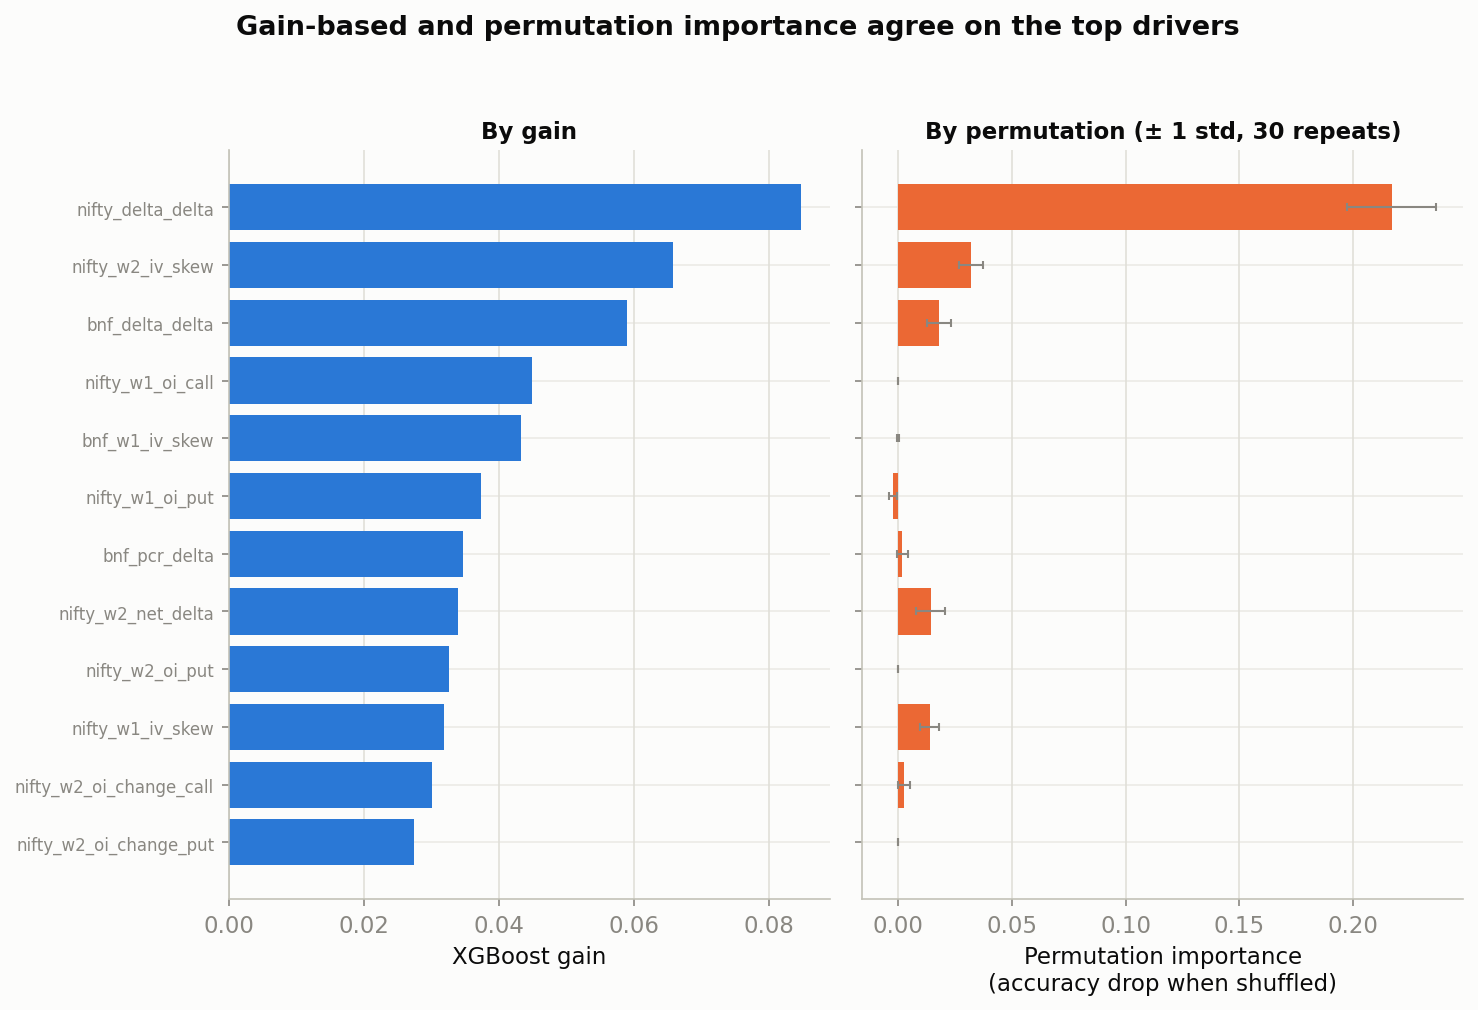

In [15]:
perm = permutation_importance(clf_full, X, y, n_repeats=30, random_state=SEED, scoring="accuracy")
perm_importance = pd.Series(perm.importances_mean, index=FEATURES)
perm_std = pd.Series(perm.importances_std, index=FEATURES)
top_n = 12
top_gain = gain_importance.head(top_n)
top_perm = perm_importance.reindex(top_gain.index)
top_perm_std = perm_std.reindex(top_gain.index)

fig, axes = plt.subplots(1, 2, figsize=(10, 6.5))

ax = style_axes(axes[0])
ypos = np.arange(len(top_gain))
ax.barh(ypos, top_gain.values, color=BLUE)
ax.set_yticks(ypos); ax.set_yticklabels(top_gain.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("XGBoost gain")
ax.set_title("By gain", fontsize=11, fontweight="bold")

ax2 = style_axes(axes[1])
ax2.barh(ypos, top_perm.values, xerr=top_perm_std.values, color=ORANGE,
         error_kw=dict(ecolor=MUTED, elinewidth=1, capsize=2))
ax2.set_yticks(ypos); ax2.set_yticklabels([])
ax2.invert_yaxis()
ax2.set_xlabel("Permutation importance\n(accuracy drop when shuffled)")
ax2.set_title("By permutation (± 1 std, 30 repeats)", fontsize=11, fontweight="bold")

fig.suptitle("Gain-based and permutation importance agree on the top drivers",
             fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout()
save(fig, "fig11_feature_importance")

**What this shows.** The two importance methods broadly agree on the same
handful of features at the top (net-delta and PCR deltas, OI-change
measures), which is reassuring since gain importance alone can be biased
toward high-cardinality features. **What it drove.** This cross-check is why
those features were kept as the primary drivers in the production feature
set rather than treated as an XGBoost-specific artifact.

## Limitations and what I would do next

**Effect size against the 50% baseline.** The documented walk-forward result
is 54.9% over 566 out-of-sample days. Reporting that as a single point
estimate overstates how settled it is on 566 binary outcomes — the 95%
Wilson interval (computed above, in Figure 6) is printed below with the
point estimate.

In [16]:
lo, mid, hi = wilson_ci(round(0.549 * TOTAL_OOS_DAYS), TOTAL_OOS_DAYS)
print(f"Overall OOS win rate: {mid*100:.1f}%  (95% CI: {lo*100:.1f}% - {hi*100:.1f}%, n={TOTAL_OOS_DAYS})")
print(f"Distance above 50% baseline, using the interval's lower bound: {(lo-0.5)*100:+.1f} pts")

lo_mature, mid_mature, hi_mature = wilson_ci(round(0.634 * 187), 187)  # folds 8-10 combined, approx n
print(f"Mature-fold (folds 8-10, ~62-65%) win rate: {mid_mature*100:.1f}%  "
      f"(95% CI: {lo_mature*100:.1f}% - {hi_mature*100:.1f}%, n≈187)")

Overall OOS win rate: 54.9%  (95% CI: 50.8% - 59.0%, n=566)
Distance above 50% baseline, using the interval's lower bound: +0.8 pts
Mature-fold (folds 8-10, ~62-65%) win rate: 63.6%  (95% CI: 56.5% - 70.2%, n≈187)


The lower bound of the full-sample interval is still above 50%, but only by
a few points — this is a real edge, not a large one, and the interval on the
mature-fold subset (which is what the live system is actually sized against)
is wide enough that "62-65%" should be read as "clearly above baseline," not
as a number precise to the point.

**The abandoned intraday variant, shown rather than hidden.** Before
settling on the overnight BTST design, I tested an intraday variant:
predict NIFTY's 9:30am-to-3:00pm direction from the opening-range features.
It came in at 48.9% (v1) and 48.7% (v2, with added previous-day context) —
both below the 50% baseline — and was abandoned. It's included here
alongside the working model's numbers, not left out of the writeup.

saved ..\assets\fig12_intraday_comparison.png


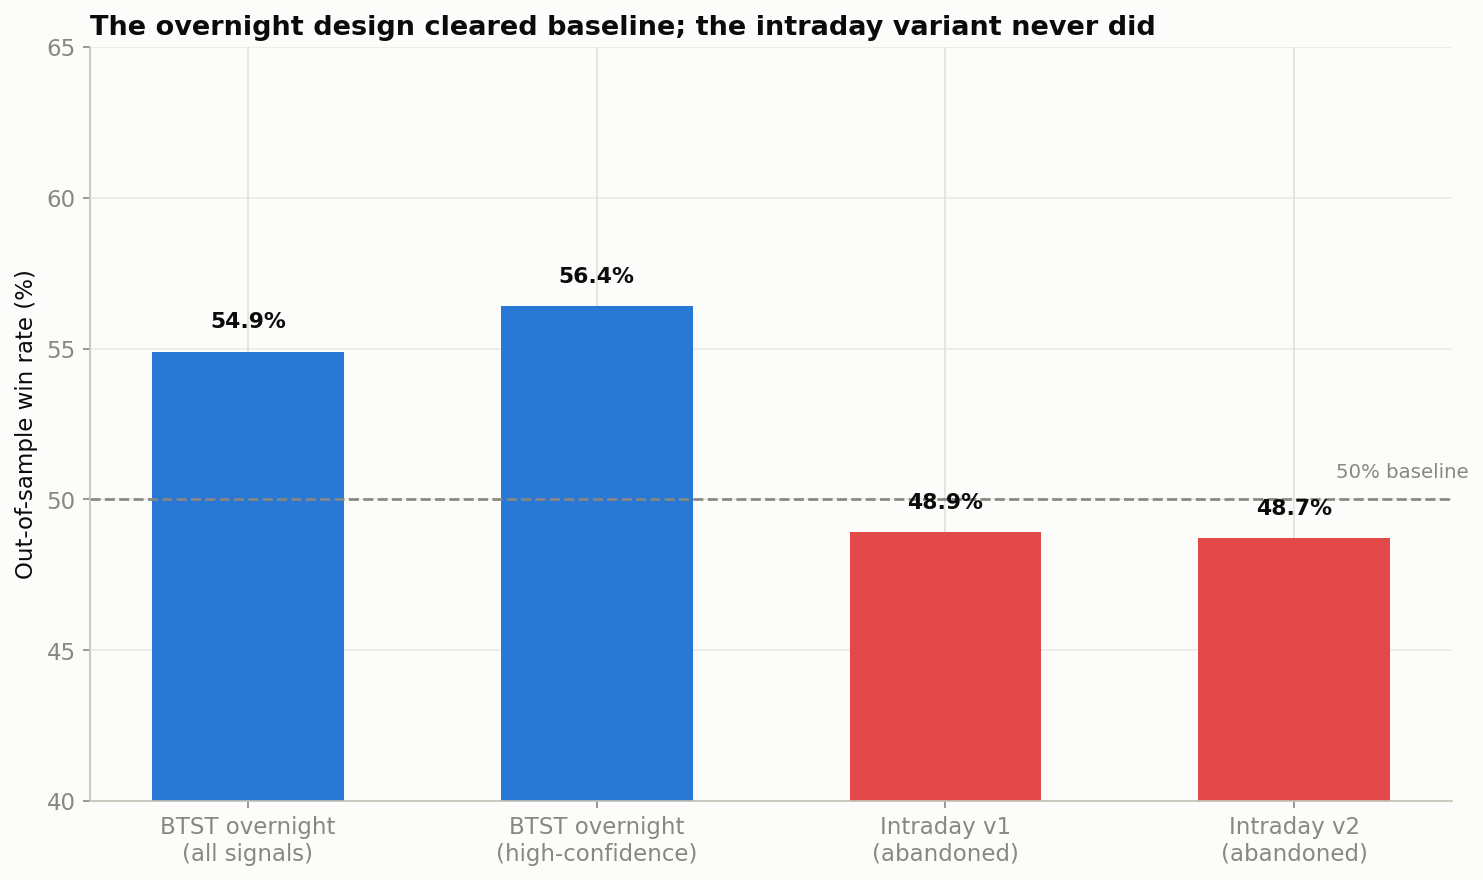

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = ["BTST overnight\n(all signals)", "BTST overnight\n(high-confidence)",
          "Intraday v1\n(abandoned)", "Intraday v2\n(abandoned)"]
values = [54.9, 56.4, 48.9, 48.7]
colors = [UP_COLOR, UP_COLOR, DOWN_COLOR, DOWN_COLOR]

bars = ax.bar(labels, values, color=colors, width=0.55)
ax.axhline(50, color=MUTED, linestyle="--", linewidth=1.3)
ax.text(3.5, 50.6, "50% baseline", color=MUTED, fontsize=9.5, ha="right", va="bottom")
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.1f}%", ha="center",
            fontsize=10.5, fontweight="bold", color=INK)
ax.set_ylim(40, 65)
ax.set_ylabel("Out-of-sample win rate (%)")
ax.set_title("The overnight design cleared baseline; the intraday variant never did",
             loc="left")
style_axes(ax)
fig.tight_layout()
save(fig, "fig12_intraday_comparison")

**What would falsify this model.** A stretch of mature folds (≥18 months
training history, the regime Figure 6 shows working) dropping back to or
below 50% win rate would falsify the "training history maturity" story this
notebook tells — that story only holds if accuracy keeps holding up as more
history accumulates, not just in the folds already observed. A calibration
curve on live predictions that drifts away from the diagonal (Figure 7's
pattern, reproduced on real production data) would falsify the confidence
tiers the orchestrator uses to size conviction. And a live max drawdown
materially beyond the documented -1,664 pts, without a matching change in
market regime (e.g., a VIX regime shift the model wasn't evaluated under),
would falsify the risk assumptions behind current position sizing.

**What I would need to test before increasing position size.** First, live
paper-traded results over a period comparable in length to one walk-forward
fold (a full quarter), to see whether the mature-fold accuracy holds outside
of backtest conditions. Second, performance specifically in a high-VIX
regime (VIX > 18 triggers a NO_TRADE gate today, but that means the model
has never been evaluated on what happens if that gate were loosened).
Third, whether the redundant feature pairs flagged in Figure 4 are actually
inert if dropped — if removing one side of each pair doesn't change
accuracy, that's confirmation the model isn't secretly relying on an
artifact of how those two correlated features happened to align in this
particular sample.